# Evaluating Random Forest Performance

## Import required libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import skew
# from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.utils import Bunch

In [2]:
root_path = Path(".").absolute()
data_path = root_path / "data"
data_path.mkdir(exist_ok=True)

%matplotlib inline

## Load the California Housing dataset

In [3]:
# I make a solution because of network problem
def fetch_california_housing_offline() -> Bunch:
    with open(data_path / "california_housing.rst") as f:
        descr = f.read()

    raw = np.loadtxt(data_path / "cadata.txt", skiprows=27, encoding="iso-8859-1")

    eigenmatrix = np.column_stack([
        raw[:, 1],                 # MedInc
        raw[:, 2],                 # HouseAge
        raw[:, 3] / raw[:, 6],     # AveRooms
        raw[:, 4] / raw[:, 6],     # AveBedrms
        raw[:, 5],                 # Population
        raw[:, 5] / raw[:, 6],     # AveOccup
        raw[:, 7],                 # Latitude
        raw[:, 8]                  # Longitude
    ])
    target_var = raw[:, 0] / 100000.0

    feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

    return Bunch(data=eigenmatrix, target=target_var, feature_names=feature_names, DESCR=descr)

In [4]:
# data = fetch_california_housing()
data = fetch_california_housing_offline()
X: np.ndarray = data.data
y: np.ndarray = data.target

## Print the description of the California Housing dataset

In [5]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

## Exercise

<p>Split the data into training and testing sets. Reserve 20% of the data for evaluation.</p>

In [6]:
split_data: list[np.ndarray] = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = split_data

## Explore the training data

In [7]:
eda = pd.DataFrame(X_train)
eda.columns = data.feature_names
eda.loc[:, "MedHouseVal"] = y_train
eda.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## How are the median house prices distributed?

Text(0, 0.5, 'Frequency')

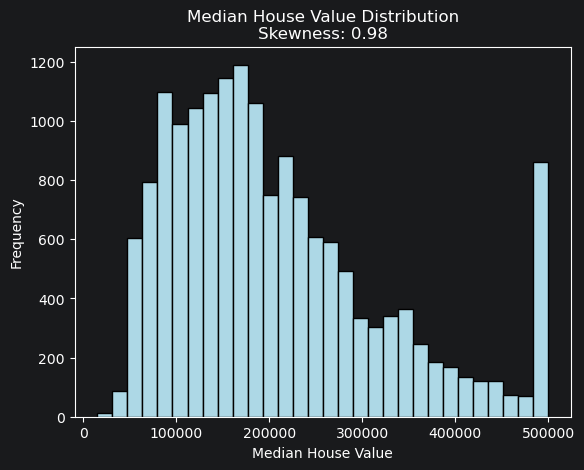

In [8]:
plt.hist(1e5 * y_train, bins=30, color="lightblue", edgecolor="black")
plt.title(f"Median House Value Distribution\nSkewness: {skew(y_train):.2f}")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

<p>Evidently the distribution is skewed and there are quite a few clipped values at around \$500,000.</p>

## Model fitting and prediction

<p>Let's fit a random forest regression model to the data and use it to make median house price predictions. Use the default parameters, which includes using 100 base estimators, or regression trees.</p>

In [9]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

y_pred_test = rf_regressor.predict(X_test)

## Estimate out-of-sample MAE, MSE, RMSE, and $R^2$

In [10]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

In [11]:
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2}")

Mean Absolute Error (MAE): 0.3275
Mean Squared Error (MSE): 0.2554
Root Mean Squared Error (RMSE): 0.5053
R² Score: 0.8051230593157366


<p>The mean absolute error is \$32,750. So, on average, predicted median house prices are off by \$33k.</p>
<p>Mean squared error is less intuitive to interpret, but is usually what is being minimized by the model fit. On the other hand, taking the square root of MSE yields a dollar value, here RMSE is \$50,530.</p>
<p>An R-squared score of 0.80 is not considered very high. It means the model explains about 80% of the variance in median house prices, although this interpretation can be misleading for complex data with nonlinear relationships, skewed values, and outliers. R-squared can still be useful for comparing models though.</p>
<p>These statistics alone don't explain any details about the performance of the model. For example, where did the model do well or poorly?</p>
<p>We aren't done yet!</p>

## Plot Actual and Predicted values

Text(0.5, 1.0, 'Random Forest Regression - Actual vs. Predicted Values')

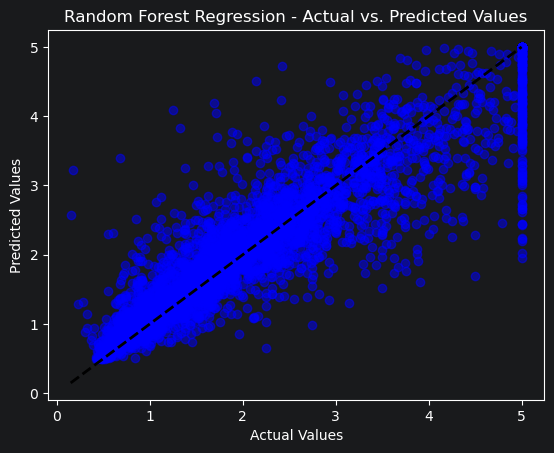

In [12]:
plt.scatter(y_test, y_pred_test, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression - Actual vs. Predicted Values")

## Plot the histogram of the residual errors (dollars)

Average Error: -1242
Standard Deviation of Error: 50518


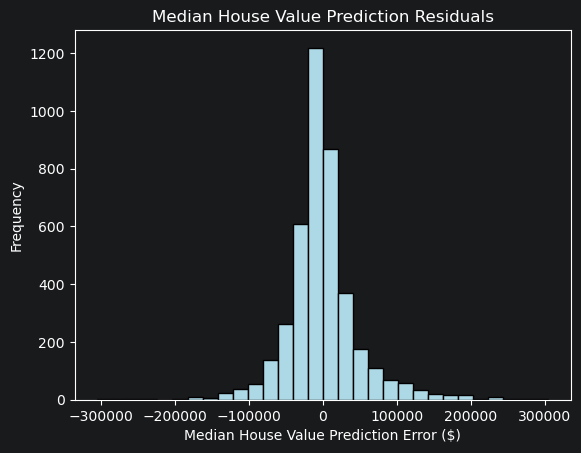

In [13]:
residuals = 1e5 * (y_test - y_pred_test)

plt.hist(residuals, bins=30, color="lightblue", edgecolor="black")
plt.title("Median House Value Prediction Residuals")
plt.xlabel("Median House Value Prediction Error ($)")
plt.ylabel("Frequency")
print(f"Average Error: {str(int(np.mean(residuals)))}")
print(f"Standard Deviation of Error: {str(int(np.std(residuals)))}")

<p>The residuals are normally distributed with a very small average error and a standard deviation of about \$50,000.</p>

## Plot the model residual errors by median house value

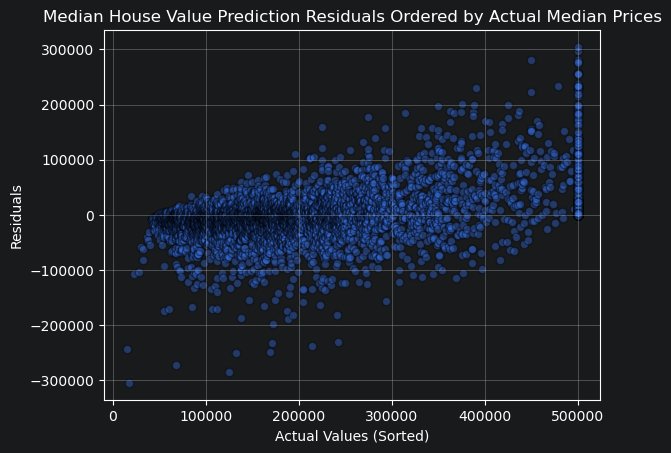

In [14]:
residuals_df = pd.DataFrame({"Actual": 1e5 * y_test, "Residuals": residuals})
residuals_df = residuals_df.sort_values(by="Actual")

plt.scatter(residuals_df.loc[:, "Actual"], residuals_df.loc[:, "Residuals"], marker="o", alpha=0.4, ec="k")
plt.title("Median House Value Prediction Residuals Ordered by Actual Median Prices")
plt.xlabel("Actual Values (Sorted)")
plt.ylabel("Residuals")
plt.grid(True)

<p>Although we saw a small average residual of only -\$1400, you can see from this plot that the average error as a function of median house price is actually increasing from negative to positive values. In other words, lower median prices tend to be overpredicted while higher median prices tend to be underpredicted.</p>

## Display the feature importances as a bar chart

Text(0.5, 1.0, 'Feature Importances in Random Forest Regression')

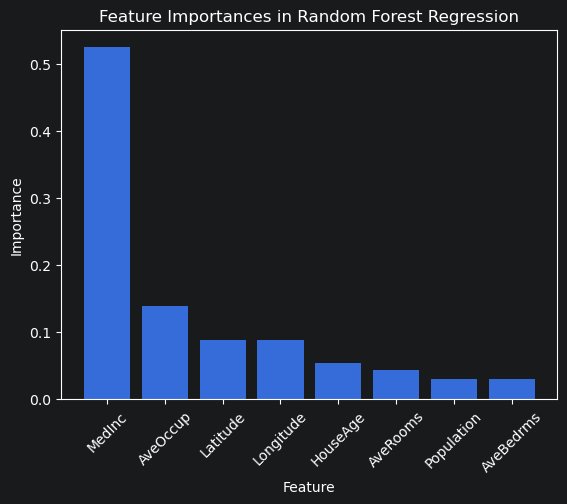

In [15]:
importances = rf_regressor.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.feature_names

plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")

<p>It makes sense that median incomes and house prices would be correlated, so it's not surprising that median income is the most important feature. I would think that location must be a significant factor.</p>
<p>Since location is implied by two separate variables, latitude and longitude that share equal importances, we might speculate that location is really the second most important feature. This is because replacing latitude and longitude with a categorical location at an appropriate level of granularity (suburb, city, etc.) would likely have a combined lat/lng importance, which might outweigh average occupancy.</p>

<p>Compared to linear regression, random forest regression is quite robust against outliers and skewed distributions. This is because random forest regression doesn't make any assumptions about the data distribution, where linear regression performs best with normally distributed data.</p>
<p>Standardizing the data isn't necessary like it is for distance-based algorithms like KNN or SVMs. Regarding the clipped values, there is no variability in those values. Removing them in preprocessing might help the model to better explain the actual variance in the data. </p>
<p>The clipped values can also bias the predictions. Also, these clipped values can mislead evaluation metrics. As you've learned from this lab, it's crucially important for you to visualize your results.</p>

****
This is the end of the file.
****